# 03 — Diagnóstico visual da modelagem (GLM vs GBM)

Os gráficos que **explicam** os modelos de frequência: como cada variável entra no preço, quão bem o modelo calibra, e *por que* (e onde) o GBM ganha do GLM.

Importa o motor (`src/pricing`) e usa o snapshot de `data/processed`.

> **Nota:** validação **temporal** (teste no tempo) não cabe no freMTPL2 (snapshot sem datas) — fica para o **v2**, com a base ES (2015–2018, com renovações).

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

ROOT = None
for base in [pathlib.Path('.'), pathlib.Path('..')]:
    if (base / 'src' / 'pricing').exists():
        ROOT = base.resolve()
        break
sys.path.insert(0, str(ROOT))

from src.pricing.data import CATEGORICAL, NUMERIC
from src.pricing.frequency import build_frequency_pipeline
from src.pricing.gbm import build_frequency_gbm

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

proc = ROOT / 'data' / 'processed'
def load(name):
    pq = proc / (name + '.parquet')
    cs = proc / (name + '.csv')
    return pd.read_parquet(pq) if pq.exists() else pd.read_csv(cs)

df = load('freMTPL2_modeling')
enc = OrdinalEncoder(dtype=np.float64)
X = df[CATEGORICAL + NUMERIC].copy()
X[CATEGORICAL] = enc.fit_transform(df[CATEGORICAL])

train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
Xtr, Xte = X.loc[train_idx], X.loc[test_idx]
tr, te = df.loc[train_idx], df.loc[test_idx]

glm = build_frequency_pipeline().fit(Xtr, tr['Frequency'], glm__sample_weight=tr['Exposure'])
gbm = build_frequency_gbm().fit(Xtr, tr['Frequency'], sample_weight=tr['Exposure'])
pred_glm = glm.predict(Xte)
pred_gbm = gbm.predict(Xte)
print('Modelos ajustados. Teste:', f'{len(te):,}')

Modelos ajustados. Teste: 135,603


## 1. Relatividades do GLM — como cada fator entra no preço

Num GLM log-linear, `exp(coef)` é o **efeito multiplicativo** de cada fator na frequência. Acima de 1 encarece, abaixo barateia. É a forma como atuários leem o modelo (numéricas estão por desvio-padrão, pois padronizadas).

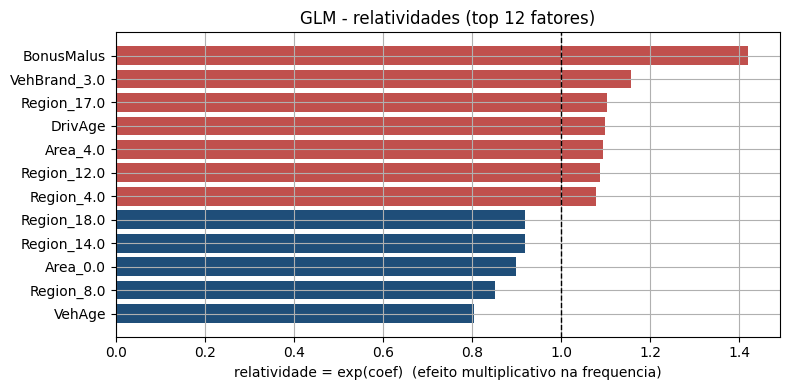

In [2]:
pre = glm.named_steps['pre']
reg = glm.named_steps['glm']
names = [n.replace('cat__', '').replace('num__', '') for n in pre.get_feature_names_out()]
rel = np.exp(reg.coef_)
idx = np.argsort(np.abs(np.log(rel)))[::-1][:12]
idx = idx[np.argsort(rel[idx])]

colors = ['#c0504d' if rel[i] > 1 else '#1f4e79' for i in idx]
plt.barh([names[i] for i in idx], rel[idx], color=colors)
plt.axvline(1.0, color='black', lw=1, ls='--')
plt.xlabel('relatividade = exp(coef)  (efeito multiplicativo na frequencia)')
plt.title('GLM - relatividades (top 12 fatores)')
plt.tight_layout()
plt.show()

## 2. Observado vs previsto, por variável

Para cada faixa, a frequência **observada** vs a **prevista** por GLM e GBM. Mostra onde cada modelo calibra — e onde o GBM captura curvatura que o GLM linear achata.

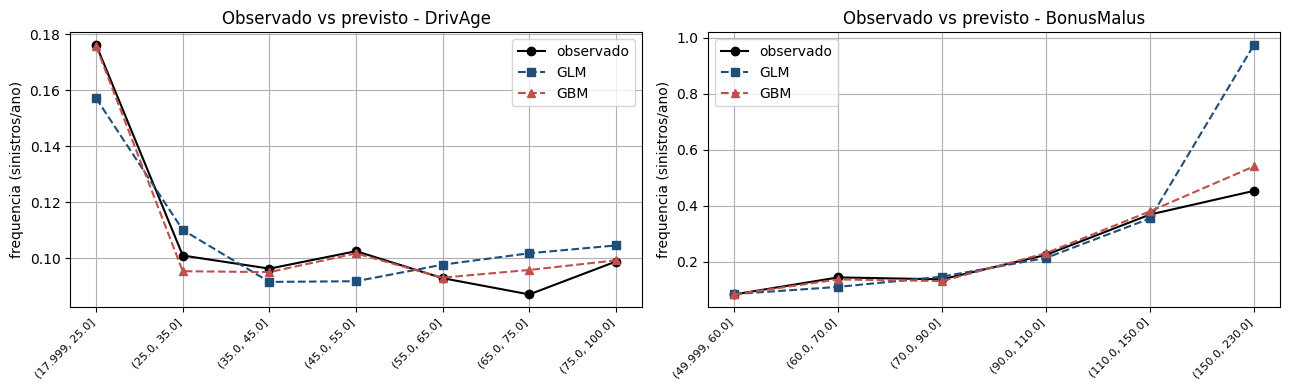

In [3]:
work = pd.DataFrame({
    'Exposure': te['Exposure'].to_numpy(),
    'ClaimNb': te['ClaimNb'].to_numpy(),
    'p_glm': pred_glm,
    'p_gbm': pred_gbm,
    'DrivAge': te['DrivAge'].to_numpy(),
    'BonusMalus': te['BonusMalus'].to_numpy(),
})

def obs_pred(col, bins):
    b = pd.cut(work[col], bins=bins, include_lowest=True)
    g = work.groupby(b, observed=True)
    return pd.DataFrame({
        'observado': g.apply(lambda d: d['ClaimNb'].sum() / d['Exposure'].sum()),
        'GLM': g.apply(lambda d: np.average(d['p_glm'], weights=d['Exposure'])),
        'GBM': g.apply(lambda d: np.average(d['p_gbm'], weights=d['Exposure'])),
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
specs = [(axes[0], 'DrivAge', [18, 25, 35, 45, 55, 65, 75, 100]),
         (axes[1], 'BonusMalus', [50, 60, 70, 90, 110, 150, 230])]
for ax, col, bins in specs:
    t = obs_pred(col, bins)
    x = range(len(t))
    ax.plot(x, t['observado'], 'o-', label='observado', color='black')
    ax.plot(x, t['GLM'], 's--', label='GLM', color='#1f4e79')
    ax.plot(x, t['GBM'], '^--', label='GBM', color='#c0504d')
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(i) for i in t.index], rotation=45, ha='right', fontsize=8)
    ax.set_title('Observado vs previsto - ' + col)
    ax.set_ylabel('frequencia (sinistros/ano)')
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Lift chart — poder de discriminação

Apólices ordenadas por risco previsto, em decis de exposição igual. A frequência observada deve **subir** do decil 1 ao 10; quanto mais íngreme, melhor o modelo separa bom de mau risco.

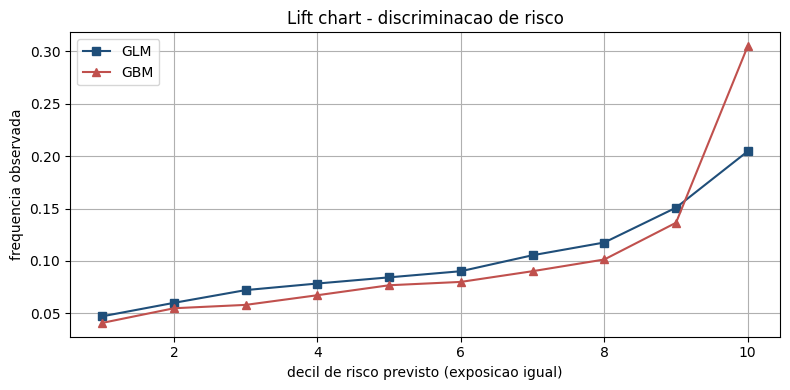

In [4]:
def lift(pred, n=10):
    o = np.argsort(pred)
    exp = te['Exposure'].to_numpy()[o]
    cnb = te['ClaimNb'].to_numpy()[o]
    cum = np.cumsum(exp) / exp.sum()
    binid = np.minimum((cum * n).astype(int), n - 1)
    return np.array([cnb[binid == k].sum() / exp[binid == k].sum() for k in range(n)])

x = range(1, 11)
plt.plot(x, lift(pred_glm), 's-', label='GLM', color='#1f4e79')
plt.plot(x, lift(pred_gbm), '^-', label='GBM', color='#c0504d')
plt.xlabel('decil de risco previsto (exposicao igual)')
plt.ylabel('frequencia observada')
plt.title('Lift chart - discriminacao de risco')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Curva de Lorenz / Gini — ranqueamento

Resume o poder de ordenação num número. Quanto **mais afastada da diagonal** (maior Gini), melhor o modelo concentra os sinistros nos riscos que ele aponta como piores.

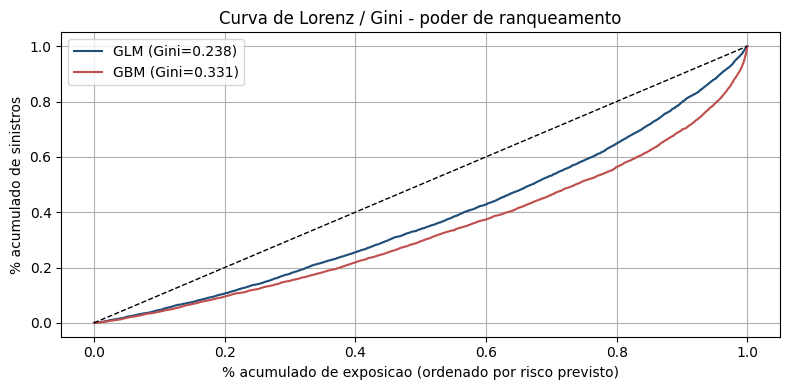

In [5]:
def lorenz(pred):
    o = np.argsort(pred)
    exp = te['Exposure'].to_numpy()[o]
    cnb = te['ClaimNb'].to_numpy()[o]
    cx = np.insert(np.cumsum(exp) / exp.sum(), 0, 0)
    cy = np.insert(np.cumsum(cnb) / cnb.sum(), 0, 0)
    area = np.sum((cx[1:] - cx[:-1]) * (cy[1:] + cy[:-1]) / 2)
    return cx, cy, 1 - 2 * area

cx_g, cy_g, gini_g = lorenz(pred_glm)
cx_b, cy_b, gini_b = lorenz(pred_gbm)
plt.plot(cx_g, cy_g, label=f'GLM (Gini={gini_g:.3f})', color='#1f4e79')
plt.plot(cx_b, cy_b, label=f'GBM (Gini={gini_b:.3f})', color='#c0504d')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('% acumulado de exposicao (ordenado por risco previsto)')
plt.ylabel('% acumulado de sinistros')
plt.title('Curva de Lorenz / Gini - poder de ranqueamento')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Leitura dos diagnósticos

- **Relatividades** tornam o GLM auditável: dá para defender cada fator perante um regulador.
- **Observado vs previsto** mostra o GBM acompanhando melhor a curvatura (ex.: idade), enquanto o GLM linear suaviza.
- **Lift** e **Gini** confirmam que o GBM **ranqueia melhor** o risco — mas o ganho vem dos mesmos drivers (ver SHAP no `02_modeling`), logo é confiável.
- **Trade-off:** GLM transparente (regulatório) vs GBM preciso (auditado por SHAP + estes diagnósticos).

**Validação temporal** (teste no tempo) entra no **v2**, com a base ES que tem datas e renovações.